# Amazon Product Data Analysis

In [19]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/Aman739-code/E_G1_DVACapstone2/08822a26dd4f60d6c3df650c694c0bf6fa1c52fd/data/processed/cleaned_data.csv")

## 1. Data Loading and Initial Setup

This section loads the Amazon product dataset and sets up the necessary libraries for analysis.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Initial Data Exploration

We'll start by looking at the basic structure and characteristics of our dataset.

In [21]:
df.head()

,title,rating,number_of_reviews,bought_in_last_month,listed_price,is_best_seller,is_sponsored,buy_box_availability,delivery_details,image_url,product_url,collected_at,current_price,has_coupon,is_sustainable
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,159.00,0,1,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,89.68,1,1
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6000,15.99,0,1,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,9.99,0,0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2000,349.00,0,1,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,314.00,0,0
3,Complete Protect: One plan covers all eligible...,4.0,4380,0,16.99,0,0,NaN,NaN,https://m.media-amazon.com/images/I/71tZ0n2xP9...,/Asurion-Complete-Protect/dp/B07RZ3LSHM/ref=sr...,2025-08-21 11:14:29,16.99,1,0
4,Amazon Basics 48-Pack AA Alkaline High-Perform...,4.7,865598,100000,14.99,1,0,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/81iJ+tnLAD...,/AmazonBasics-Performance-Alkaline-Batteries-C...,2025-08-21 11:14:29,14.99,0,1


In [22]:
df.shape

(30926, 15)

In [23]:
df.columns

Index(['title', 'rating', 'number_of_reviews', 'bought_in_last_month',
       'listed_price', 'is_best_seller', 'is_sponsored',
       'buy_box_availability', 'delivery_details', 'image_url', 'product_url',
       'collected_at', 'current_price', 'has_coupon', 'is_sustainable'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30926 entries, 0 to 30925
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 30926 non-null  object 
 1   rating                30926 non-null  float64
 2   number_of_reviews     30926 non-null  int64  
 3   bought_in_last_month  30926 non-null  int64  
 4   listed_price          30926 non-null  float64
 5   is_best_seller        30926 non-null  int64  
 6   is_sponsored          30926 non-null  int64  
 7   buy_box_availability  27880 non-null  object 
 8   delivery_details      30813 non-null  object 
 9   image_url             30926 non-null  object 
 10  product_url           29137 non-null  object 
 11  collected_at          30926 non-null  object 
 12  current_price         30926 non-null  float64
 13  has_coupon            30926 non-null  int64  
 14  is_sustainable        30926 non-null  int64  
dtypes: float64(3), int6

In [25]:
df.describe()

,rating,number_of_reviews,bought_in_last_month,listed_price,is_best_seller,is_sponsored,current_price,has_coupon,is_sustainable
count,30926.000000,30926.000000,30926.000000,30926.000000,30926.000000,30926.000000,30926.000000,30926.000000,30926.000000
mean,4.424365,3147.951012,1234.736144,231.496871,0.007275,0.226282,212.607587,0.062989,0.074662
std,0.380262,13369.459734,6317.003045,427.482821,0.084987,0.418431,389.888111,0.242947,0.262850
min,1.000000,0.000000,0.000000,3.590000,0.000000,0.000000,2.490000,0.000000,0.000000
25%,4.300000,77.000000,50.000000,29.990000,0.000000,0.000000,25.990000,0.000000,0.000000
50%,4.500000,376.000000,100.000000,80.050000,0.000000,0.000000,77.000000,0.000000,0.000000
75%,4.700000,2029.000000,400.000000,199.990000,0.000000,0.000000,197.950000,0.000000,0.000000
max,5.000000,865598.000000,100000.000000,5399.000000,1.000000,1.000000,4699.000000,1.000000,1.000000


## 3. Feature Engineering and Data Preparation

In this section, we create new features and prepare the data for further analysis, including converting data types and creating new flags.

In [26]:
# Convert datetime
df["collected_at"] = pd.to_datetime(df["collected_at"], errors="coerce")

# Create availability flag
df["is_available"] = df["buy_box_availability"].notna().astype(int)

# Create discount features
df["discount"] = df["listed_price"] - df["current_price"]
df["discount_pct"] = df["discount"] / df["listed_price"]

# Optional: clean delivery (keep as is for now)
df.head()

,title,rating,number_of_reviews,bought_in_last_month,listed_price,is_best_seller,is_sponsored,buy_box_availability,delivery_details,image_url,product_url,collected_at,current_price,has_coupon,is_sustainable,is_available,discount,discount_pct
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,159.00,0,1,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,89.68,1,1,1,69.32,0.435975
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6000,15.99,0,1,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,9.99,0,0,1,6.00,0.375235
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2000,349.00,0,1,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,314.00,0,0,1,35.00,0.100287
3,Complete Protect: One plan covers all eligible...,4.0,4380,0,16.99,0,0,NaN,NaN,https://m.media-amazon.com/images/I/71tZ0n2xP9...,/Asurion-Complete-Protect/dp/B07RZ3LSHM/ref=sr...,2025-08-21 11:14:29,16.99,1,0,0,0.00,0.000000
4,Amazon Basics 48-Pack AA Alkaline High-Perform...,4.7,865598,100000,14.99,1,0,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/81iJ+tnLAD...,/AmazonBasics-Performance-Alkaline-Batteries-C...,2025-08-21 11:14:29,14.99,0,1,1,0.00,0.000000


### Missing Value Analysis

Let's check for any missing values in the dataset.

In [27]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_df

,missing_count,missing_pct
buy_box_availability,3046,9.849318
product_url,1789,5.784777
delivery_details,113,0.365388
title,0,0.000000
rating,0,0.000000
number_of_reviews,0,0.000000
is_best_seller,0,0.000000
listed_price,0,0.000000
is_sponsored,0,0.000000
bought_in_last_month,0,0.000000


### Product Categorization

We define a function to categorize products based on their title and URL, and then apply it to create a new 'category' column.

In [28]:
def categorize_product(title, url):
    text = (str(title) + " " + str(url)).lower()

    # Phones
    if any(k in text for k in [
        "iphone", "smartphone", "mobile phone", "android phone"
    ]):
        return "Phones"

    # Laptops
    elif any(k in text for k in [
        "laptop", "macbook", "notebook", "chromebook"
    ]):
        return "Laptops"

    # Headphones / Earbuds
    elif any(k in text for k in [
        "headphone", "earphone", "earbud", "airpods", "headset"
    ]):
        return "Headphones"

    # Cameras
    elif any(k in text for k in [
        "camera", "dslr", "mirrorless", "gopro", "lens", "tripod"
    ]):
        return "Cameras"

    # Storage
    elif any(k in text for k in [
        "ssd", "hdd", "hard drive", "flash drive", "pen drive",
        "memory card", "storage"
    ]):
        return "Storage"

    # Printers & Scanners
    elif any(k in text for k in [
        "printer", "scanner", "ink", "toner"
    ]):
        return "Printers & Scanners"

    # TV & Display
    elif any(k in text for k in [
        "tv", "television", "monitor", "display", "projector"
    ]):
        return "TV & Display"

    # Power & Batteries
    elif any(k in text for k in [
        "battery", "power bank", "ups", "inverter"
    ]):
        return "Power & Batteries"

    # Chargers & Cables
    elif any(k in text for k in [
        "charger", "charging cable", "usb cable", "type c", "adapter"
    ]):
        return "Chargers & Cables"

    # Networking
    elif any(k in text for k in [
        "router", "modem", "wifi", "ethernet", "network switch"
    ]):
        return "Networking"

    # Speakers
    elif any(k in text for k in [
        "speaker", "soundbar", "subwoofer"
    ]):
        return "Speakers"

    # Wearables
    elif any(k in text for k in [
        "smartwatch", "fitness band", "wearable", "apple watch"
    ]):
        return "Wearables"

    # Gaming
    elif any(k in text for k in [
        "gaming", "xbox", "playstation", "ps5", "controller", "console"
    ]):
        return "Gaming"

    # Smart Home
    elif any(k in text for k in [
        "smart home", "alexa", "echo", "google home", "smart bulb", "smart plug"
    ]):
        return "Smart Home"

    # Fallback
    elif text.strip() == "" or text == "nan":
        return None

    else:
        return "Other Electronics"

In [29]:
df['category'] = df.apply(
    lambda x: categorize_product(x['title'], x['product_url']),
    axis=1
)

In [33]:
df.head()

,title,rating,number_of_reviews,bought_in_last_month,listed_price,is_best_seller,is_sponsored,buy_box_availability,delivery_details,image_url,product_url,collected_at,current_price,has_coupon,is_sustainable,is_available,discount,discount_pct,category
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,159.00,0,1,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,89.68,1,1,1,69.32,0.435975,Phones
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6000,15.99,0,1,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,9.99,0,0,1,6.00,0.375235,Phones
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2000,349.00,0,1,Add to cart,"Delivery Mon, Sep 1",https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,314.00,0,0,1,35.00,0.100287,Phones
3,Complete Protect: One plan covers all eligible...,4.0,4380,0,16.99,0,0,NaN,NaN,https://m.media-amazon.com/images/I/71tZ0n2xP9...,/Asurion-Complete-Protect/dp/B07RZ3LSHM/ref=sr...,2025-08-21 11:14:29,16.99,1,0,0,0.00,0.000000,Other Electronics
4,Amazon Basics 48-Pack AA Alkaline High-Perform...,4.7,865598,100000,14.99,1,0,Add to cart,"Delivery Fri, Aug 29",https://m.media-amazon.com/images/I/81iJ+tnLAD...,/AmazonBasics-Performance-Alkaline-Batteries-C...,2025-08-21 11:14:29,14.99,0,1,1,0.00,0.000000,Other Electronics


## 4. Exploratory Data Analysis (EDA)

This section performs exploratory data analysis to understand data distributions, relationships, and potential patterns.

In [34]:
df.tail()

,title,rating,number_of_reviews,bought_in_last_month,listed_price,is_best_seller,is_sponsored,buy_box_availability,delivery_details,image_url,product_url,collected_at,current_price,has_coupon,is_sustainable,is_available,discount,discount_pct,category
30921,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1,100,195.99,0,0,NaN,"FREE delivery Thu, Sep 4Or fastest delivery Tu...",https://m.media-amazon.com/images/I/51KCB+egEs...,/Elgato-4K-Pro-Internal-Capture/dp/B0DLR3WQWR/...,2025-08-30 19:56:33,195.99,0,0,0,0.00,0.000000,Power & Batteries
30922,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20,200,89.99,0,0,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery Mo...",https://m.media-amazon.com/images/I/51jV+o1LZE...,/Arlo-Essential-Spotlight-Camera-Surveillance/...,2025-08-30 19:56:33,89.99,1,0,1,0.00,0.000000,Cameras
30923,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57,50,1099.99,0,0,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",https://m.media-amazon.com/images/I/71ySPkNLkG...,/GIGABYTE-FO32U2-32-3840x2160-240Hz-FreeSync-A...,2025-08-30 19:56:33,899.99,0,0,1,200.00,0.181820,TV & Display
30924,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102,500,15.98,0,0,Add to cart,"FREE delivery Thu, Sep 4 on $35 of items shipp...",https://m.media-amazon.com/images/I/411c0JFJ79...,/Monoprice-XLR-Male-4-Inch-Cable/dp/B001UJEKZ6...,2025-08-30 19:56:33,10.39,0,0,1,5.59,0.349812,Other Electronics
30925,Lorex Fusion 1080p HD Security Camera System w...,4.4,75,50,499.99,0,0,Add to cart,"FREE delivery Thu, Sep 4Or fastest delivery We...",https://m.media-amazon.com/images/I/71wTn+zoSr...,/Lorex-8-Channel-Security-Outdoor-Cameras/dp/B...,2025-08-30 19:56:33,419.99,0,0,1,80.00,0.160003,Cameras


### Distribution of Numerical Features

Visualizing the distribution of key numerical columns using histograms.

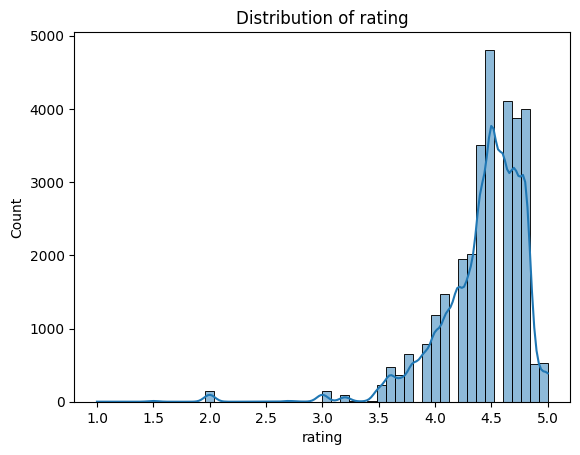

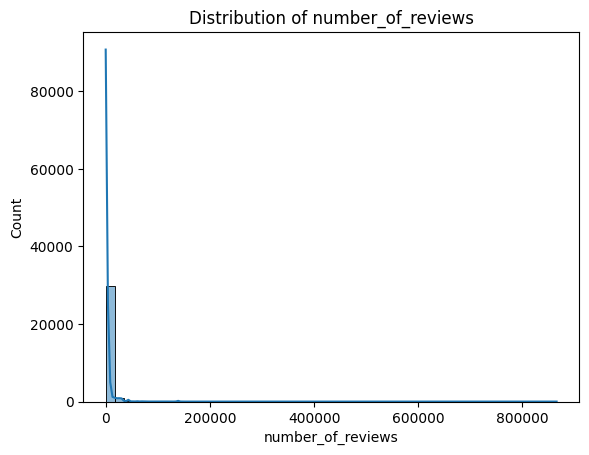

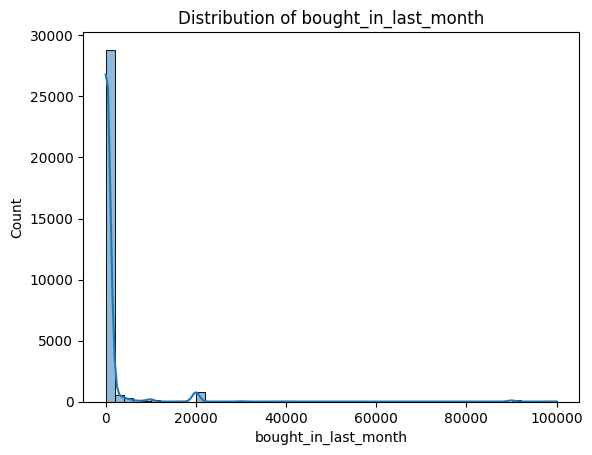

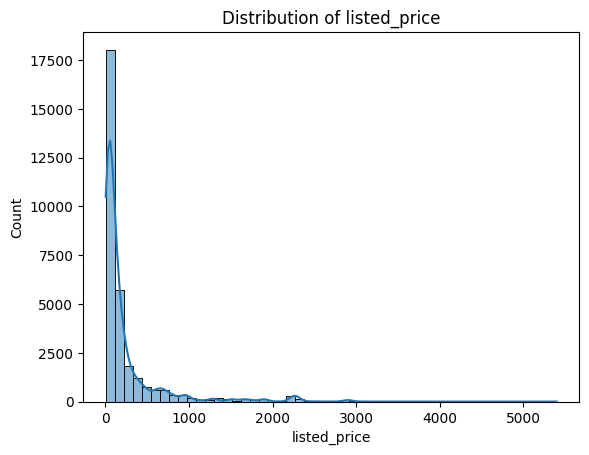

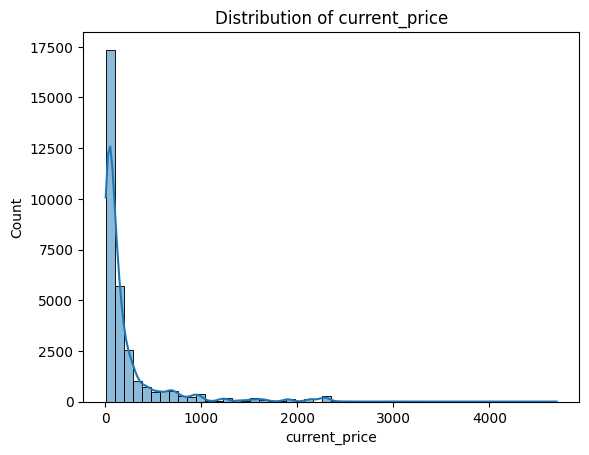

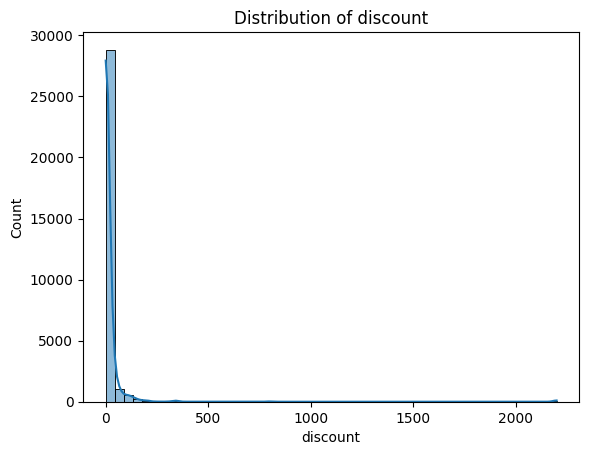

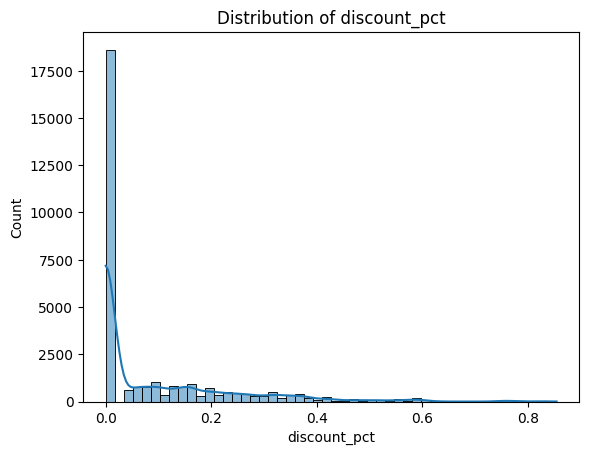

In [35]:
num_cols = [
    "rating", "number_of_reviews", "bought_in_last_month",
    "listed_price", "current_price", "discount", "discount_pct"
]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Distribution of Categorical Features

Visualizing the distribution of key categorical columns using bar plots.

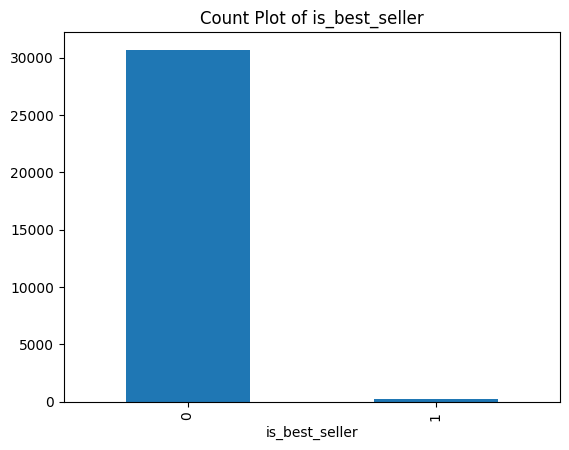

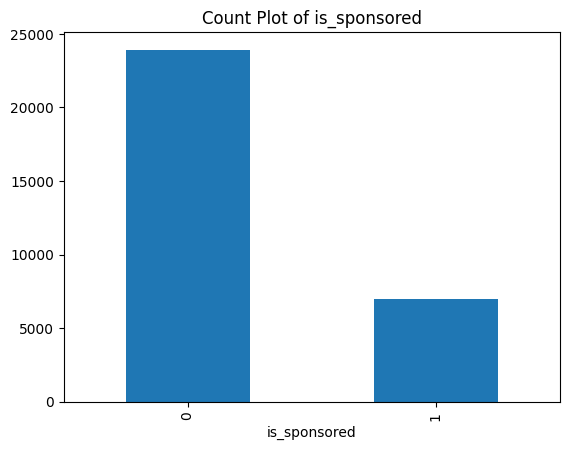

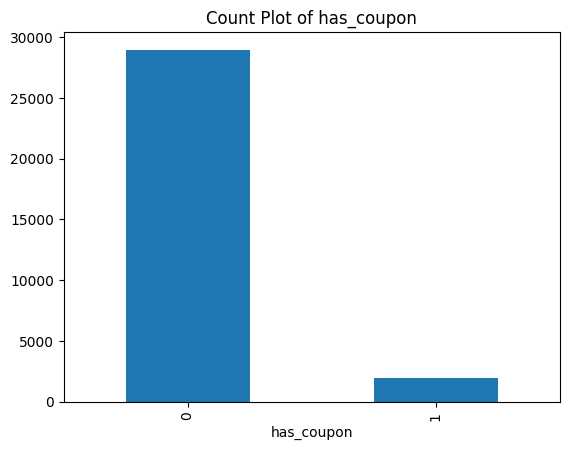

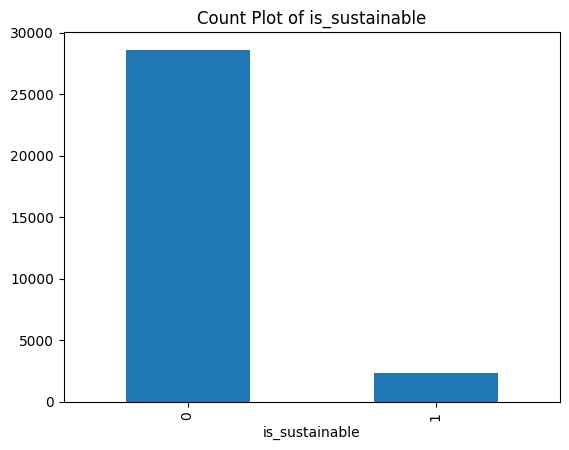

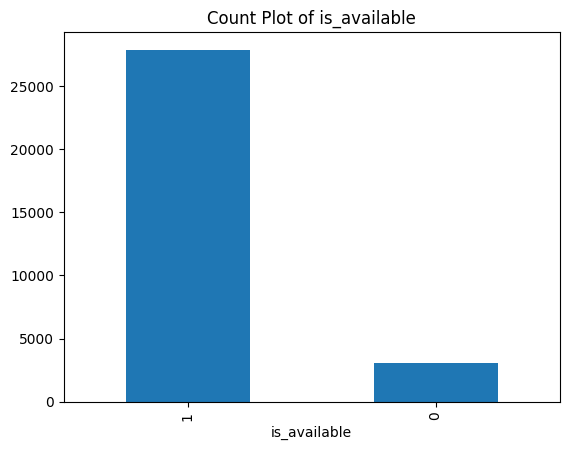

In [36]:
cat_cols = [
    "is_best_seller", "is_sponsored",
    "has_coupon", "is_sustainable", "is_available"
]

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Count Plot of {col}")
    plt.show()

### Outlier Detection (Boxplots)

Using boxplots to identify potential outliers and understand the spread of numerical features.

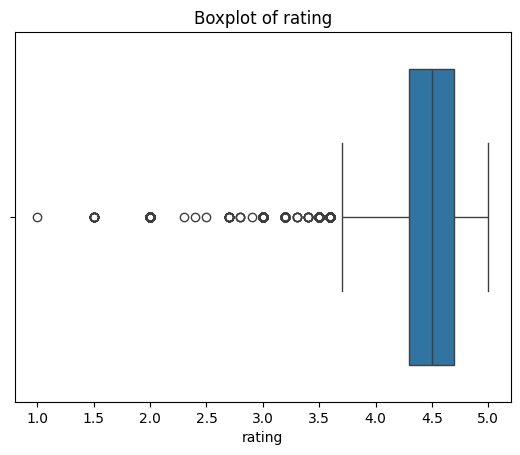

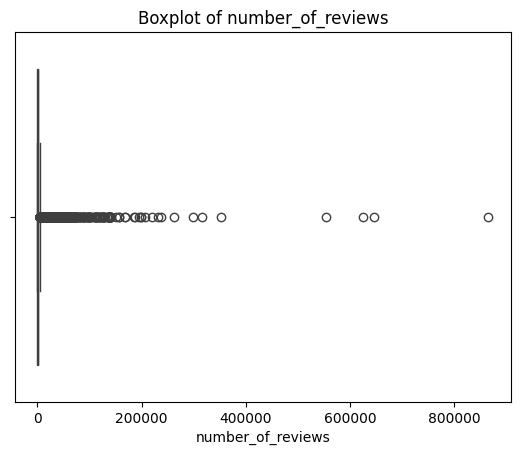

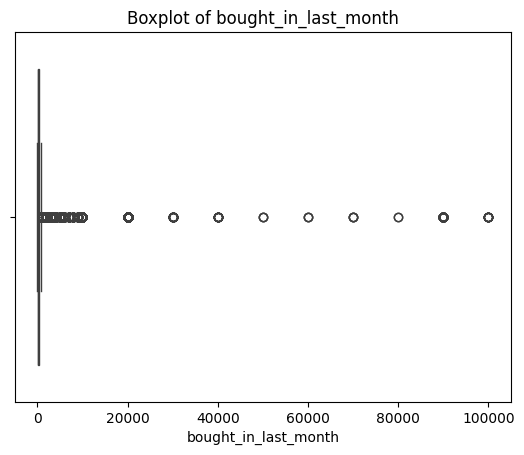

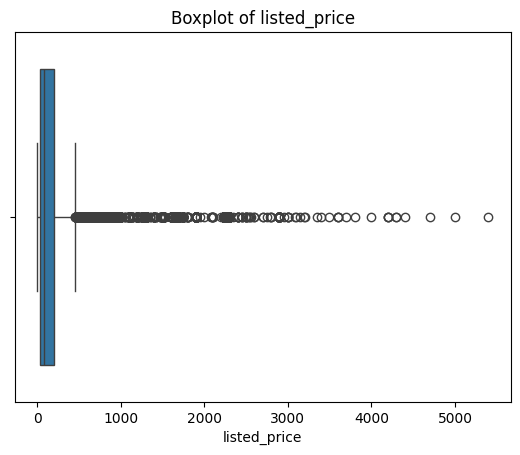

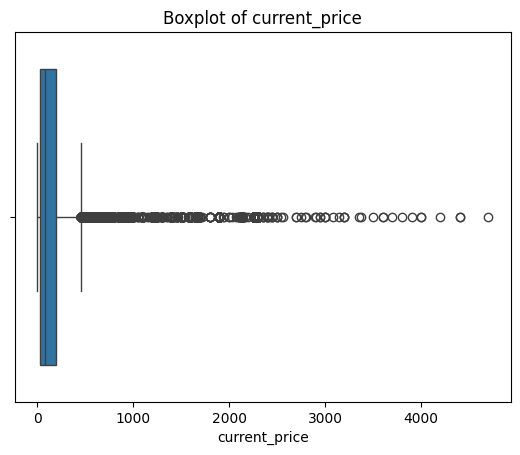

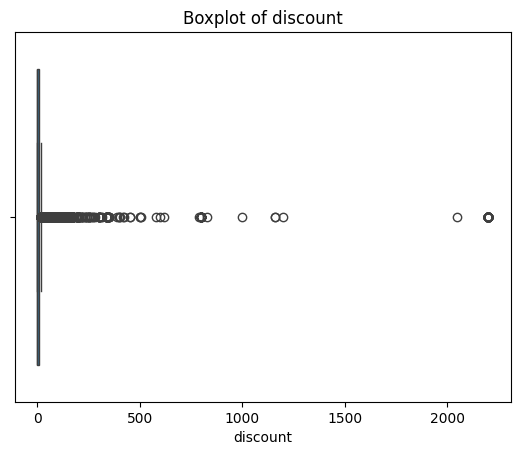

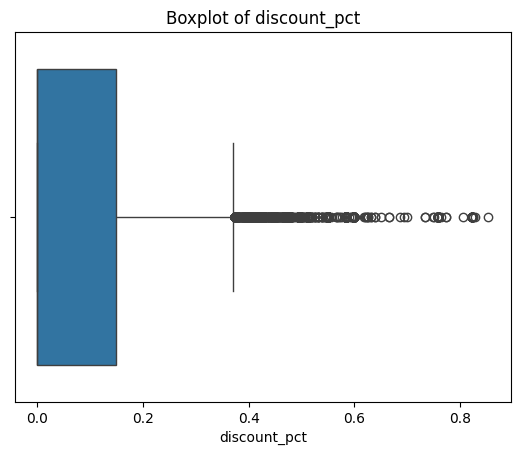

In [37]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Correlation Matrix

Examining the correlations between numerical features using a heatmap.

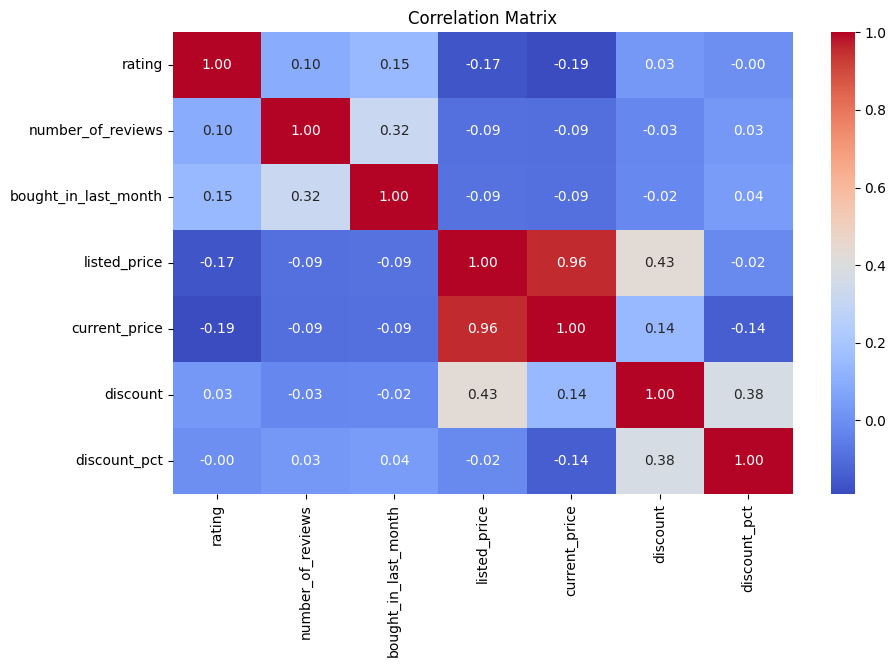

In [38]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Relationships Between Key Variables

Exploring relationships between important variables like rating, reviews, price, and sales.

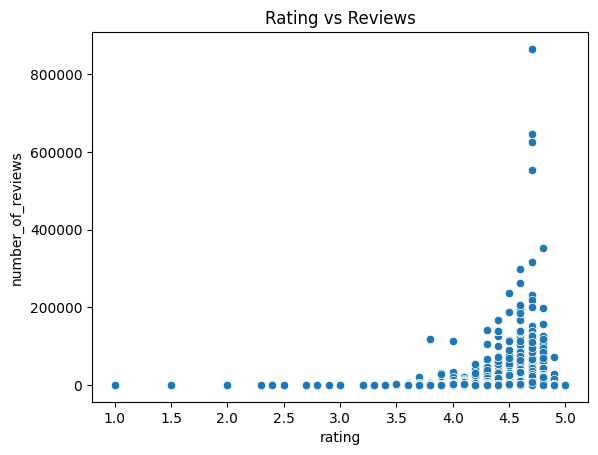

In [39]:
sns.scatterplot(x="rating", y="number_of_reviews", data=df)
plt.title("Rating vs Reviews")
plt.show()

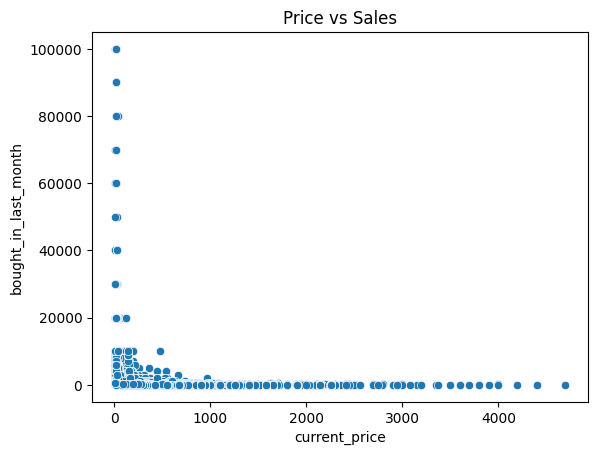

In [40]:
sns.scatterplot(x="current_price", y="bought_in_last_month", data=df)
plt.title("Price vs Sales")
plt.show()

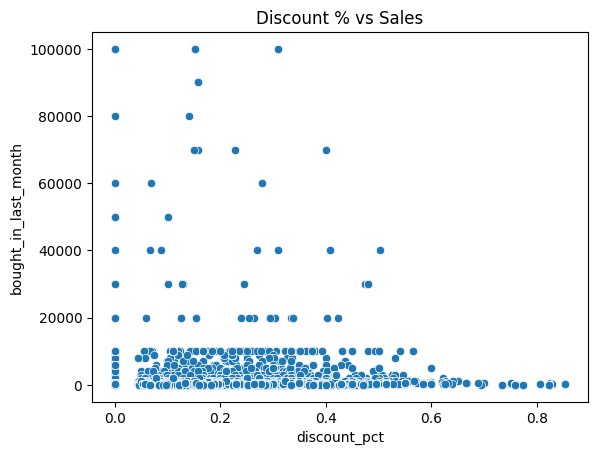

In [41]:
sns.scatterplot(x="discount_pct", y="bought_in_last_month", data=df)
plt.title("Discount % vs Sales")
plt.show()

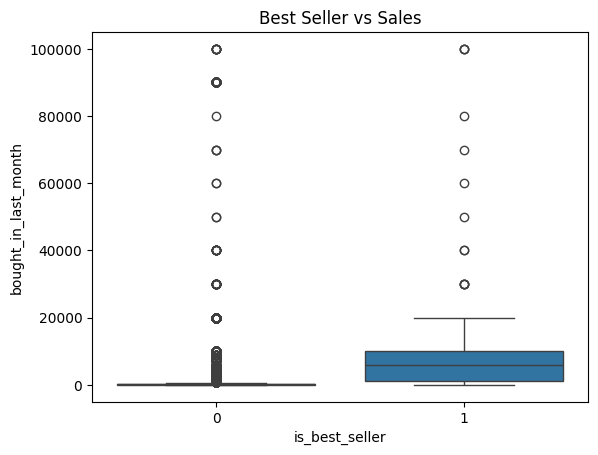

In [42]:
sns.boxplot(x="is_best_seller", y="bought_in_last_month", data=df)
plt.title("Best Seller vs Sales")
plt.show()

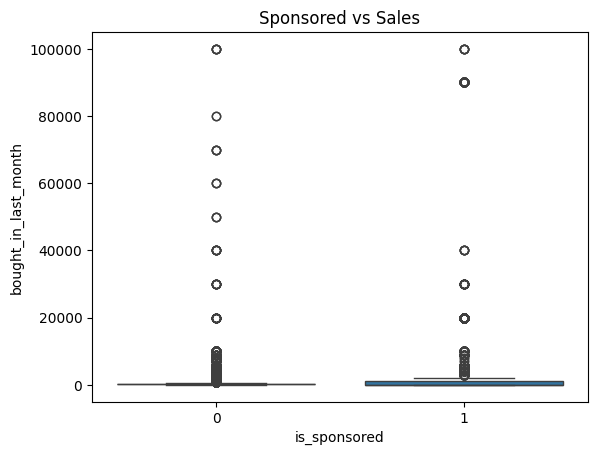

In [43]:
sns.boxplot(x="is_sponsored", y="bought_in_last_month", data=df)
plt.title("Sponsored vs Sales")
plt.show()

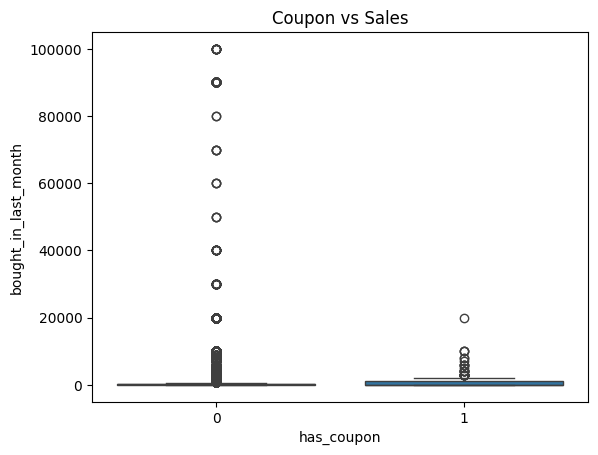

In [44]:
sns.boxplot(x="has_coupon", y="bought_in_last_month", data=df)
plt.title("Coupon vs Sales")
plt.show()

### Duplicate Check

Checking for any duplicate rows in the dataset.

In [45]:
df.duplicated().sum()

np.int64(0)